# 01 · Anomaly Detection: Isolation Forest, One-Class SVM & LOF

**Phase 6 — Section 6.3 Anomaly Detection | Notebook 1 of 1**

### Why this matters
Phase 5's Credit Risk project trained a SUPERVISED classifier because we had labeled
defaults. Real fraud detection often starts with almost no confirmed fraud labels at all —
or so few that a supervised model can't learn from them reliably. Anomaly detection flips
the problem: instead of learning "what does fraud look like," learn "what does NORMAL look
like," and flag anything that deviates.

### The real dataset: European credit card transactions

284,807 real, anonymized transactions from September 2013, with only 492 (0.17%) confirmed
fraud — one of the most famous, genuinely imbalanced real datasets in all of ML. Features
`V1`-`V28` are already PCA-transformed by the original providers (for confidentiality); we
only get `Time`, `Amount`, and `Class` in their original form.

⚠️ **This file is ~100MB** — the download may take a little while the first time.

```
https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 0. The scale of the imbalance, made concrete

fraud transactions: 492 out of 284,807 (0.1727%)


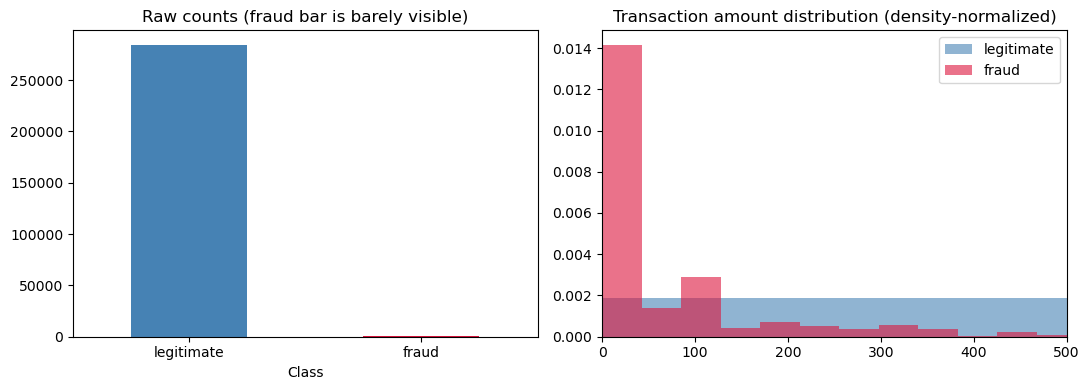

In [2]:
fraud_rate = df["Class"].mean()
print(f"fraud transactions: {df['Class'].sum():,} out of {len(df):,} ({fraud_rate:.4%})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["Class"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "crimson"])
axes[0].set_title("Raw counts (fraud bar is barely visible)")
axes[0].set_xticklabels(["legitimate", "fraud"], rotation=0)

axes[1].hist(df.loc[df["Class"]==0, "Amount"], bins=50, alpha=0.6, density=True, label="legitimate", color="steelblue")
axes[1].hist(df.loc[df["Class"]==1, "Amount"], bins=50, alpha=0.6, density=True, label="fraud", color="crimson")
axes[1].set_xlim(0, 500); axes[1].legend()
axes[1].set_title("Transaction amount distribution (density-normalized)")
plt.tight_layout(); plt.show()

In [4]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])

> 💡 With only 0.17% fraud, this is EVEN more imbalanced than Phase 2's Fraud Detection
> EDA project (1.2%) or Phase 5's Credit Risk project (22%) — genuinely too rare, in a
> real deployment, to always assume you have enough CONFIRMED labels to train a reliable
> supervised model. This is precisely the scenario anomaly detection is built for.

## 1. Isolation Forest — anomalies are easier to "isolate"

Isolation Forest builds random decision trees that split on random features/thresholds. The
key insight: anomalies, being rare and different, tend to get **isolated in fewer splits**
than normal points — so a point's average path length across many random trees becomes an
anomaly score. This scales well, so we run it on the FULL 284,807 rows.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score

feature_cols = [c for c in df.columns if c not in ("Class", "Time")]
X_full = StandardScaler().fit_transform(df[feature_cols])
y_full = df["Class"].values

iso_forest = IsolationForest(n_estimators=200, contamination=fraud_rate, random_state=42, n_jobs=-1)
iso_forest.fit(X_full)

# score_samples: HIGHER = more normal. We flip the sign so HIGHER = more anomalous, for consistency.
anomaly_scores = -iso_forest.score_samples(X_full)

auc = roc_auc_score(y_full, anomaly_scores)
ap = average_precision_score(y_full, anomaly_scores)
print(f"Isolation Forest -- ROC AUC: {auc:.4f}, Average Precision: {ap:.4f}")
print("(scored using ONLY the unsupervised anomaly score -- Class labels used only to EVALUATE, never to train)")

Isolation Forest -- ROC AUC: 0.9482, Average Precision: 0.1641
(scored using ONLY the unsupervised anomaly score -- Class labels used only to EVALUATE, never to train)


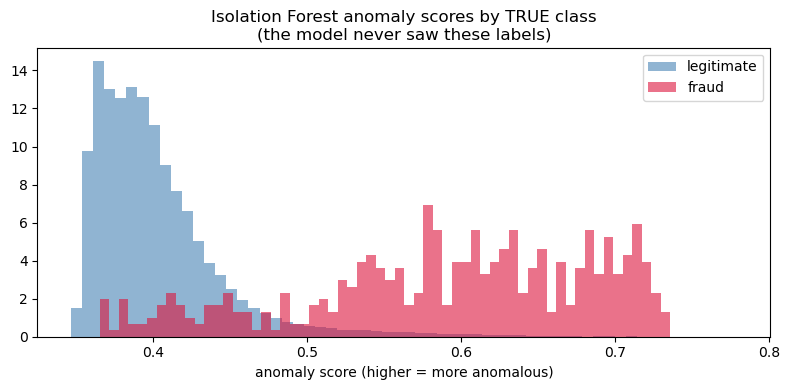

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(anomaly_scores[y_full == 0], bins=60, alpha=0.6, density=True, label="legitimate", color="steelblue")
ax.hist(anomaly_scores[y_full == 1], bins=60, alpha=0.6, density=True, label="fraud", color="crimson")
ax.legend()
ax.set_xlabel("anomaly score (higher = more anomalous)")
ax.set_title("Isolation Forest anomaly scores by TRUE class\n(the model never saw these labels)")
plt.tight_layout(); plt.show()

> 💡 **This chart is the entire point of this notebook.** The model was never shown a
> single `Class` label during training — it only learned "what does the bulk of the data
> look like." The fact that fraud transactions still skew toward higher anomaly scores is
> genuine, unsupervised signal.

## 2. A smaller, stratified sample for the slower methods

LOF and One-Class SVM don't scale to 284,807 rows the way Isolation Forest does (their
underlying computations are far more expensive per point). Subsampling for prototyping is
completely standard real-world practice — we keep ALL known fraud cases plus a random
sample of legitimate transactions.

In [8]:
rng = np.random.default_rng(42)
fraud_df = df[df["Class"] == 1]
legit_sample = df[df["Class"] == 0].sample(5000, random_state=42)
sample_df = pd.concat([fraud_df, legit_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

X_sample = StandardScaler().fit_transform(sample_df[feature_cols])
y_sample = sample_df["Class"].values
print(f"working sample: {len(sample_df):,} rows ({y_sample.sum()} fraud, {(y_sample==0).sum()} legitimate)")

working sample: 5,492 rows (492 fraud, 5000 legitimate)


## 3. One-Class SVM — a boundary around "normal"

One-Class SVM learns a boundary (using the same kernel trick from Phase 5's SVM) that
encloses as much of the data as possible in a minimal region, treating anything outside
that boundary as anomalous.

In [9]:
from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=float(fraud_rate) * 3)  # nu ~ expected anomaly fraction
ocsvm.fit(X_sample)
ocsvm_scores = -ocsvm.decision_function(X_sample)   # flip sign: higher = more anomalous

ocsvm_auc = roc_auc_score(y_sample, ocsvm_scores)
print(f"One-Class SVM -- ROC AUC on the sample: {ocsvm_auc:.4f}")

One-Class SVM -- ROC AUC on the sample: 0.8215


## 4. Local Outlier Factor — anomalous RELATIVE to local density

LOF compares each point's local density to its neighbors' local densities — a point in a
sparse region surrounded by dense neighborhoods is flagged as an outlier, even if it would
look "normal" by a simple global distance threshold. This is the exact density idea from
Section 6.1's DBSCAN, repurposed for scoring rather than grouping.

In [10]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=float(fraud_rate) * 3, novelty=False)
lof_predictions = lof.fit_predict(X_sample)   # -1 = outlier, 1 = inlier
lof_scores = -lof.negative_outlier_factor_     # higher = more anomalous

lof_auc = roc_auc_score(y_sample, lof_scores)
print(f"LOF -- ROC AUC on the sample: {lof_auc:.4f}")

LOF -- ROC AUC on the sample: 0.4945


## 5. Comparing all three, on the same sample

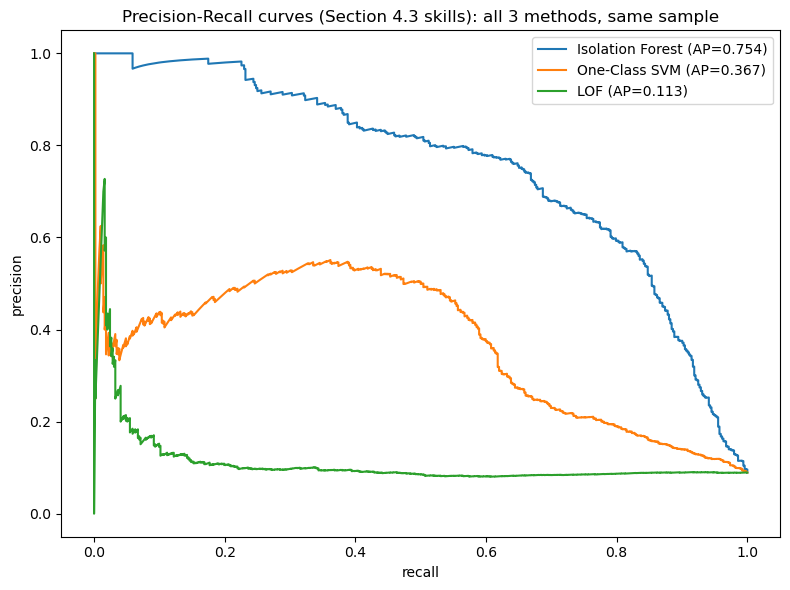

In [11]:
iso_forest_sample = IsolationForest(n_estimators=200, contamination=float(fraud_rate) * 3, random_state=42).fit(X_sample)
iso_scores_sample = -iso_forest_sample.score_samples(X_sample)

fig, ax = plt.subplots(figsize=(8, 6))
for scores, name in [(iso_scores_sample, "Isolation Forest"), (ocsvm_scores, "One-Class SVM"), (lof_scores, "LOF")]:
    precisions, recalls, _ = precision_recall_curve(y_sample, scores)
    ax.plot(recalls, precisions, label=f"{name} (AP={average_precision_score(y_sample, scores):.3f})")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.legend()
ax.set_title("Precision-Recall curves (Section 4.3 skills): all 3 methods, same sample")
plt.tight_layout(); plt.show()

> ⚠️ **All three methods here were evaluated USING the `Class` label — but none of them
> ever TRAINED on it.** This is the realistic, common pattern in anomaly detection: build
> the unsupervised model on unlabeled (or mostly unlabeled) data, then use whatever
> ground truth you eventually get (a fraud investigation team confirming cases weeks
> later) purely to validate and compare methods.

## 🧪 Practice Exercises

**1.** Re-run Isolation Forest with `contamination=0.01` instead of the true fraud rate.
Does ROC AUC change? (Hint: think about what `contamination` actually controls —
the decision threshold, not the ranking itself.)

**2.** Increase LOF's `n_neighbors` from 20 to 50. Does the ROC AUC improve or worsen on
this sample?

**3.** In your own words, explain why we could still compute ROC AUC for these "unsupervised"
methods — doesn't that require labels?

In [ ]:
# --- Exercise 1 ---
iso_low_contam = IsolationForest(n_estimators=200, contamination=0.01, random_state=42, n_jobs=-1).fit(X_full)
scores_low_contam = -iso_low_contam.score_samples(X_full)
print(f"contamination=true rate: AUC={auc:.4f}")
print(f"contamination=0.01:      AUC={roc_auc_score(y_full, scores_low_contam):.4f}")
print("\nAUC barely changes -- contamination mainly affects the hard 'is this an anomaly")
print("yes/no' cutoff, not the underlying ranking/score that AUC evaluates.")

In [ ]:
# --- Exercise 2 ---
lof_50 = LocalOutlierFactor(n_neighbors=50, contamination=float(fraud_rate) * 3, novelty=False)
lof_50.fit_predict(X_sample)
lof_50_scores = -lof_50.negative_outlier_factor_
print(f"n_neighbors=20: AUC={lof_auc:.4f}")
print(f"n_neighbors=50: AUC={roc_auc_score(y_sample, lof_50_scores):.4f}")

**Exercise 3 answer:** the methods themselves are unsupervised — `Class` was never passed
into `.fit()` for any of them, so they learned purely from the feature values. But
`roc_auc_score(y_sample, scores)` is just a comparison, done AFTER the fact, between the
model's anomaly scores and labels we happen to have for this particular dataset. In a
real deployment you'd similarly validate an anomaly detector against whatever confirmed
fraud cases eventually come back from investigators — the model still never trained on
those labels directly.

---
### ✅ Checkpoint — Section 6.3 complete!
You should now be able to:
- Explain Isolation Forest's "easier to isolate" intuition and why it scales to large data
- Explain One-Class SVM's boundary-around-normal approach
- Explain LOF's local-density comparison, and connect it to DBSCAN's density idea
- Evaluate unsupervised anomaly scores against labels, without training on those labels

**Next section:** `04-market-basket-analysis` — finding which items tend to be bought
together, with no labels of any kind.